<a href="https://colab.research.google.com/github/H1af2e3m4a5n6n/data-science-estudos/blob/main/_BigData_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análise de Big Data com PySpark


**Dataset:** Netflix Titles  
**Tecnologias:** PySpark · Parquet· Hadoop · Matplotlib  

---
###  Índice
1. Configuração do Ambiente
2. Carregamento e Limpeza dos Dados
3. Análise Exploratória (EDA)
4. Simulação de Grande Volume
5. Performance e Lazy Evaluation
6. Particionamento e Parquet
7. **INTEGRAÇÃO — Hadoop HDFS (simulado)**
8. Visualizações Avançadas
9. Conclusão e Comparativo

## 1. Configuração do Ambiente

In [ ]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS NECESSÁRIAS
# ============================================================
!pip install pyspark --quiet
!pip install google-cloud-bigquery --quiet
!pip install db-dtypes --quiet        # suporte a tipos BigQuery
!pip install pandas-gbq --quiet       # alternativa pandas → BigQuery

print("✅ Dependências instaladas com sucesso!")

In [ ]:
# ============================================================
# IMPORTAÇÃO DA SparkSession
# Spark é o motor de processamento distribuído
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, regexp_extract, when, expr,
    count, avg, max as spark_max,
    year, desc, split, explode, trim
)
import time
import os
import matplotlib.pyplot as plt
import pandas as pd

# Criação da sessão Spark
# shuffle.partitions: número de partições para operações de agregação
spark = SparkSession.builder \
    .appName("NetflixBigDataTema10") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

# Reduz logs verbosos para melhor leitura
spark.sparkContext.setLogLevel("ERROR")

print(f"✅ Spark versão: {spark.version}")
print(f"✅ Sessão iniciada: {spark.sparkContext.appName}")

✅ Spark versão: 4.0.2
✅ Sessão iniciada: NetflixBigDataTema10


## 2. Carregamento e Limpeza dos Dados

In [ ]:
# ============================================================
# UPLOAD DO ARQUIVO CSV
# ============================================================
from google.colab import files
uploaded = files.upload()   # Selecione o arquivo netflix_titles.csv

Saving netflix_titles.csv to netflix_titles.csv


In [ ]:
# ============================================================
# LEITURA DO CSV
# multiLine e quote evitam erros em descrições com vírgulas
# ============================================================
df = spark.read \
    .option("header", True) \
    .option("multiLine", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("inferSchema", False) \
    .csv("netflix_titles.csv")

print(f"📊 Total de registros: {df.count()}")
print(f"📋 Colunas: {df.columns}")
df.show(5, truncate=False)

📊 Total de registros: 6234
📋 Colunas: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
+--------+-------+---------------------------------------+------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+-----------------+------------+--------+--------+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------+
|show_id |type   |title                                  |director                |cast                                                                                                                                                                              |country                

In [ ]:
# ============================================================
# LIMPEZA E TRANSFORMAÇÃO DOS DADOS
# ============================================================

# Converte ano de lançamento para inteiro (try_cast evita erros)
df = df.withColumn(
    "release_year",
    expr("try_cast(release_year as int)")
)

# Extrai valor numérico da duração
df = df.withColumn(
    "duration_raw",
    regexp_extract(col("duration"), r'(\d+)', 1)
)

# Converte duração para inteiro
df = df.withColumn(
    "duration_int",
    when(col("duration_raw") != "", col("duration_raw").cast("int"))
    .otherwise(None)
)

# Remove espaços extras em campos de texto
df = df.withColumn("type", trim(col("type")))
df = df.withColumn("country", trim(col("country")))

# Remove registros sem tipo definido
df = df.filter(col("type").isNotNull())

print("✅ Dados limpos e transformados!")
df.select("title", "type", "release_year", "duration_int", "country").show(5)

✅ Dados limpos e transformados!
+--------------------+-------+------------+------------+--------------------+
|               title|   type|release_year|duration_int|             country|
+--------------------+-------+------------+------------+--------------------+
|Norm of the North...|  Movie|        2019|          90|United States, In...|
|Jandino: Whatever...|  Movie|        2016|          94|      United Kingdom|
|  Transformers Prime|TV Show|        2013|           1|       United States|
|Transformers: Rob...|TV Show|        2016|           1|       United States|
|        #realityhigh|  Movie|        2017|          99|       United States|
+--------------------+-------+------------+------------+--------------------+
only showing top 5 rows


## 3. Análise Exploratória (EDA)

In [ ]:
# ============================================================
# ANÁLISE EXPLORATÓRIA INICIAL
# ============================================================

print("=== DISTRIBUIÇÃO POR TIPO ===")
df.groupBy("type").count().orderBy(desc("count")).show()

print("=== VALORES NULOS POR COLUNA ===")
from pyspark.sql.functions import isnan, isnull, sum as spark_sum
null_counts = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])
null_counts.show()

print("=== ESTATÍSTICAS DE DURAÇÃO ===")
df.filter(col("type") == "Movie") \
  .select(avg("duration_int").alias("media_minutos"),
          spark_max("duration_int").alias("max_minutos")) \
  .show()

=== DISTRIBUIÇÃO POR TIPO ===
+-------+-----+
|   type|count|
+-------+-----+
|  Movie| 4265|
|TV Show| 1969|
+-------+-----+

=== VALORES NULOS POR COLUNA ===
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+------------+------------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|duration_raw|duration_int|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+------------+------------+
|      0|   0|    0|    1969| 570|    476|        11|           0|    10|       0|        0|          0|           0|           0|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+------------+------------+

=== ESTATÍSTICAS DE DURAÇÃO ===
+-----------------+-----------+
|    media_minutos|max_minutos|
+-----------------+-----------+
|99.10082063305978|        312|
+-----------------+-----

In [ ]:
# ============================================================
# ANÁLISE DE GÊNEROS (coluna 'listed_in')
# Cada linha pode ter múltiplos gêneros separados por vírgula
# ============================================================
df_genres = df.withColumn(
    "genre",
    explode(split(col("listed_in"), ", "))
).withColumn("genre", trim(col("genre")))

print("=== TOP 10 GÊNEROS MAIS COMUNS ===")
df_genres.groupBy("genre").count() \
    .orderBy(desc("count")) \
    .show(10)

=== TOP 10 GÊNEROS MAIS COMUNS ===
+--------------------+-----+
|               genre|count|
+--------------------+-----+
|International Movies| 1927|
|              Dramas| 1623|
|            Comedies| 1113|
|International TV ...| 1001|
|       Documentaries|  668|
|           TV Dramas|  599|
|  Action & Adventure|  597|
|  Independent Movies|  552|
|         TV Comedies|  436|
|           Thrillers|  392|
+--------------------+-----+
only showing top 10 rows


## 4. Simulação de Grande Volume

In [ ]:
# ============================================================
# SIMULAÇÃO DE GRANDE VOLUME DE DADOS
# A cada iteração o volume dobra (crescimento exponencial)
# 4 iterações = 16x o volume original
# ============================================================
df_big = df
for i in range(4):
    df_big = df_big.union(df_big)
    print(f"Iteração {i+1}: {df_big.count():,} registros")

print(f"\n✅ Total registros simulados: {df_big.count():,}")

Iteração 1: 12,468 registros
Iteração 2: 24,936 registros
Iteração 3: 49,872 registros
Iteração 4: 99,744 registros

✅ Total registros simulados: 99,744


## 5. Performance e Lazy Evaluation

In [ ]:
# ============================================================
# DEMONSTRAÇÃO DE LAZY EVALUATION
# Spark só processa quando uma ação é chamada (ex: .count())
# Transformações (.filter, .groupBy) são "lazy" — não executam ainda
# ============================================================
df_temp = df_big.filter(df_big.type == "Movie")  # ← LAZY: ainda não executou
print("Transformação criada (lazy — ainda não processou).")

inicio = time.time()
qtd = df_temp.count()                             # ← AÇÃO: agora processa
fim = time.time()

print(f"✅ Total de filmes: {qtd:,}")
print(f"⏱️  Tempo de execução: {fim - inicio:.2f}s")

Transformação criada (lazy — ainda não processou).
✅ Total de filmes: 68,240
⏱️  Tempo de execução: 2.23s


In [ ]:
# ============================================================
# MEDIÇÃO DE PERFORMANCE: COM vs SEM CACHE
# Cache mantém o DataFrame em memória para consultas repetidas
# ============================================================

# Sem cache
start = time.time()
df_big.groupBy("type").count().collect()
df_big.groupBy("release_year").count().collect()
tempo_sem_cache = time.time() - start

# Com cache
df_big.cache()   # Armazena em memória
df_big.count()   # Força o cache a ser populado

start = time.time()
df_big.groupBy("type").count().collect()
df_big.groupBy("release_year").count().collect()
tempo_com_cache = time.time() - start

print(f"⏱️  Sem cache: {tempo_sem_cache:.2f}s")
print(f"⚡ Com cache:  {tempo_com_cache:.2f}s")
print(f"📈 Ganho de performance: {((tempo_sem_cache - tempo_com_cache)/tempo_sem_cache*100):.1f}%")

⏱️  Sem cache: 3.63s
⚡ Com cache:  1.41s
📈 Ganho de performance: 61.1%


## 6. Particionamento e Parquet

In [ ]:
# ============================================================
# PARTICIONAMENTO
# Controla como os dados são divididos entre workers
# ============================================================
print(f"Partições antes: {df_big.rdd.getNumPartitions()}")
df_big = df_big.repartition(8)
print(f"Partições depois: {df_big.rdd.getNumPartitions()}")

Partições antes: 16
Partições depois: 8


In [ ]:
# ============================================================
# ARMAZENAMENTO EM FORMATO PARQUET
# Parquet: formato colunar, comprimido, eficiente para analytics
# ============================================================

# Salvando com particionamento por tipo
df_big.write \
    .mode("overwrite") \
    .partitionBy("type") \
    .parquet("netflix_parquet_particionado")

# Também salva versão sem partição para comparação
df_big.write.mode("overwrite").parquet("netflix_parquet")

print("✅ Salvo em formato Parquet (com e sem particionamento)")
print("Estrutura de diretórios:")
print(os.listdir("netflix_parquet_particionado"))

✅ Salvo em formato Parquet (com e sem particionamento)
Estrutura de diretórios:
['type=TV Show', 'type=Movie', '._SUCCESS.crc', '_SUCCESS']


In [ ]:
# ============================================================
# LEITURA DO PARQUET + PREDICATE PUSHDOWN
# Spark lê apenas as partições necessárias (não varre tudo)
# ============================================================
df_parquet = spark.read.parquet("netflix_parquet_particionado")

# Predicate pushdown: só lê a pasta 'type=Movie'
start = time.time()
df_parquet.filter(col("type") == "Movie").count()
print(f"⚡ Consulta com predicate pushdown: {time.time()-start:.2f}s")

# COMPARAÇÃO DE TAMANHO: CSV vs PARQUET
csv_size = os.path.getsize("netflix_titles.csv")
parquet_size = sum(
    os.path.getsize(f"netflix_parquet/{f}")
    for f in os.listdir("netflix_parquet")
    if f.endswith(".parquet")
)
print(f"\n📦 Tamanho CSV:     {csv_size/1024:.1f} KB")
print(f"📦 Tamanho Parquet: {parquet_size/1024:.1f} KB")
print(f"💡 Razão: Parquet inclui dados replicados ({16}x o original)")

⚡ Consulta com predicate pushdown: 0.27s

📦 Tamanho CSV:     2354.2 KB
📦 Tamanho Parquet: 9444.3 KB
💡 Razão: Parquet inclui dados replicados (16x o original)


## 7. ✅ INTEGRAÇÃO — Hadoop HDFS

> **O que é?** HDFS (Hadoop Distributed File System) é o sistema de arquivos distribuído do ecossistema Hadoop. Armazena grandes volumes de dados replicados entre múltiplos servidores.

> **No Colab:** simulamos a interface HDFS usando o sistema de arquivos local e comandos `hdfs dfs`, que em ambiente real conectariam a um cluster.

In [ ]:
# ============================================================
# INSTALAÇÃO DO HADOOP (modo pseudo-distribuído)
# Simula um cluster HDFS localmente no Colab
# ============================================================
!apt-get install -y default-jdk-headless wget --quiet

import os
HADOOP_VERSION = "3.3.6"
HADOOP_HOME = f"/usr/local/hadoop-{HADOOP_VERSION}"

if not os.path.exists(HADOOP_HOME):
    print("⬇️  Baixando Hadoop...")
    !wget -q https://downloads.apache.org/hadoop/common/hadoop-{HADOOP_VERSION}/hadoop-{HADOOP_VERSION}.tar.gz
    !tar -xzf hadoop-{HADOOP_VERSION}.tar.gz -C /usr/local/
    print("✅ Hadoop instalado!")
else:
    print("✅ Hadoop já instalado.")

# Configura variáveis de ambiente
os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["PATH"] += f":{HADOOP_HOME}/bin:{HADOOP_HOME}/sbin"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/default-java"

!hadoop version 2>/dev/null | head -1

Reading package lists...
Building dependency tree...
Reading state information...
wget is already the newest version (1.21.2-2ubuntu1.1).
The following additional packages will be installed:
  default-jre-headless openjdk-11-jdk-headless openjdk-11-jre-headless
Suggested packages:
  default-jre openjdk-11-demo openjdk-11-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  default-jdk-headless default-jre-headless openjdk-11-jdk-headless
  openjdk-11-jre-headless
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 116 MB of archives.
After this operation, 258 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 openjdk-11-jre-headless amd64 11.0.30+7-1ubuntu1~22.04 [42.6 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 default-jre-headless amd64 2:1.11-72build2 [3,042 B]
Ge

In [ ]:
# ============================================================
# CONFIGURAÇÃO DO HDFS LOCAL (pseudo-distribuído)
# ============================================================
import subprocess

# Configura core-site.xml (endereço do HDFS)
core_site = """<?xml version="1.0" encoding="UTF-8"?>
<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>hdfs://localhost:9000</value>
  </property>
</configuration>"""

# Configura hdfs-site.xml (fator de replicação = 1 pois é local)
hdfs_site = """<?xml version="1.0" encoding="UTF-8"?>
<configuration>
  <property>
    <name>dfs.replication</name>
    <value>1</value>
  </property>
  <property>
    <name>dfs.namenode.name.dir</name>
    <value>/tmp/hadoop/namenode</value>
  </property>
  <property>
    <name>dfs.datanode.data.dir</name>
    <value>/tmp/hadoop/datanode</value>
  </property>
</configuration>"""

conf_path = f"{HADOOP_HOME}/etc/hadoop"
with open(f"{conf_path}/core-site.xml", "w") as f: f.write(core_site)
with open(f"{conf_path}/hdfs-site.xml", "w") as f: f.write(hdfs_site)

# Configura o JAVA_HOME para o Hadoop
!echo "export JAVA_HOME=/usr/lib/jvm/default-java" >> {conf_path}/hadoop-env.sh

# Formata o namenode (necessário na primeira vez)
!{HADOOP_HOME}/bin/hdfs namenode -format -force 2>/dev/null
print("✅ HDFS formatado!")

✅ HDFS formatado!


In [ ]:
# ============================================================
# INICIALIZAÇÃO DO HDFS
# ============================================================
import subprocess, time

# Inicia os processos do HDFS em background
subprocess.Popen([
    f"{HADOOP_HOME}/bin/hdfs", "namenode"
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(5)  # Aguarda namenode iniciar

subprocess.Popen([
    f"{HADOOP_HOME}/bin/hdfs", "datanode"
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(5)  # Aguarda datanode iniciar

print("✅ HDFS iniciado (NameNode + DataNode)")

# Cria estrutura de diretórios no HDFS
!{HADOOP_HOME}/bin/hdfs dfs -mkdir -p /user/colab/netflix 2>/dev/null
print("✅ Diretório /user/colab/netflix criado no HDFS")

✅ HDFS iniciado (NameNode + DataNode)
✅ Diretório /user/colab/netflix criado no HDFS


In [ ]:
# ============================================================
# OPERAÇÕES HDFS — ESCRITA E LEITURA
# ============================================================

# Envia o CSV para o HDFS
!{HADOOP_HOME}/bin/hdfs dfs -put -f netflix_titles.csv /user/colab/netflix/
print("✅ CSV enviado ao HDFS")

# Lista arquivos no HDFS
print("\n📁 Arquivos no HDFS:")
!{HADOOP_HOME}/bin/hdfs dfs -ls /user/colab/netflix/

# Mostra as primeiras linhas diretamente do HDFS
print("\n📄 Primeiras linhas no HDFS:")
!{HADOOP_HOME}/bin/hdfs dfs -cat /user/colab/netflix/netflix_titles.csv 2>/dev/null | head -3

# Verifica o tamanho do arquivo no HDFS
print("\n📦 Tamanho no HDFS:")
!{HADOOP_HOME}/bin/hdfs dfs -du -h /user/colab/netflix/

✅ CSV enviado ao HDFS

📁 Arquivos no HDFS:
Found 1 items
-rw-r--r--   1 root supergroup    2410660 2026-04-16 17:03 /user/colab/netflix/netflix_titles.csv

📄 Primeiras linhas no HDFS:
show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole Howard, Jennifer Cameron, Jonathan Holmes, Lee Tockar, Lisa Durupt, Maya Kay, Michael Dobson","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies","Before planning an awesome wedding for his grandfather, a polar bear king must take back a stolen artifact from an evil archaeologist first."
80117401,Movie,Jandino: Whatever it Takes,,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,"Jandino Asporaat riffs on the challenges of raising kids and serenades the audience with a rousing

In [ ]:
# ============================================================
# LER DIRETO DO HDFS COM SPARK
# Em ambiente real, basta apontar o path hdfs://
# ============================================================
HDFS_PATH = "hdfs://localhost:9000/user/colab/netflix/netflix_titles.csv"

try:
    df_hdfs = spark.read \
        .option("header", True) \
        .option("inferSchema", False) \
        .csv(HDFS_PATH)

    print(f"✅ Lidos {df_hdfs.count():,} registros direto do HDFS!")
    df_hdfs.show(5)

    # Salva processado de volta no HDFS em formato Parquet
    OUTPUT_HDFS = "hdfs://localhost:9000/user/colab/netflix/parquet_output"
    df_hdfs.write.mode("overwrite").parquet(OUTPUT_HDFS)
    print(f"✅ Parquet salvo no HDFS: {OUTPUT_HDFS}")

except Exception as e:
    print(f"ℹ️  HDFS local pode não estar disponível nesta sessão: {e}")
    print("    Em cluster real, substitua o path por hdfs://seu-namenode:9000/...")

✅ Lidos 6,236 registros direto do HDFS!
+--------+-------+--------------------+--------------------+--------------------+--------------------+-----------------+------------+--------+--------+--------------------+--------------------+
| show_id|   type|               title|            director|                cast|             country|       date_added|release_year|  rating|duration|           listed_in|         description|
+--------+-------+--------------------+--------------------+--------------------+--------------------+-----------------+------------+--------+--------+--------------------+--------------------+
|81145628|  Movie|Norm of the North...|Richard Finn, Tim...|Alan Marriott, An...|United States, In...|September 9, 2019|        2019|   TV-PG|  90 min|Children & Family...|Before planning a...|
|80117401|  Movie|Jandino: Whatever...|                NULL|    Jandino Asporaat|      United Kingdom|September 9, 2016|        2016|   TV-MA|  94 min|     Stand-Up Comedy|"Jandino Asp

In [ ]:
# ============================================================
# COMANDOS HDFS ÚTEIS — REFERÊNCIA
# ============================================================
print("""
📚 REFERÊNCIA — Comandos HDFS mais usados:

  hdfs dfs -ls /path             → Lista arquivos
  hdfs dfs -mkdir -p /path       → Cria diretório
  hdfs dfs -put local.csv /path  → Envia arquivo local → HDFS
  hdfs dfs -get /path local.csv  → Baixa HDFS → local
  hdfs dfs -cat /path/file.csv   → Exibe conteúdo
  hdfs dfs -du -h /path          → Tamanho dos arquivos
  hdfs dfs -rm -r /path          → Remove diretório
  hdfs dfs -mv /origem /destino  → Move arquivo
  hdfs fsck /path                → Verifica integridade
""")


📚 REFERÊNCIA — Comandos HDFS mais usados:

  hdfs dfs -ls /path             → Lista arquivos
  hdfs dfs -mkdir -p /path       → Cria diretório
  hdfs dfs -put local.csv /path  → Envia arquivo local → HDFS
  hdfs dfs -get /path local.csv  → Baixa HDFS → local
  hdfs dfs -cat /path/file.csv   → Exibe conteúdo
  hdfs dfs -du -h /path          → Tamanho dos arquivos
  hdfs dfs -rm -r /path          → Remove diretório
  hdfs dfs -mv /origem /destino  → Move arquivo
  hdfs fsck /path                → Verifica integridade



## 8. Visualizações Avançadas

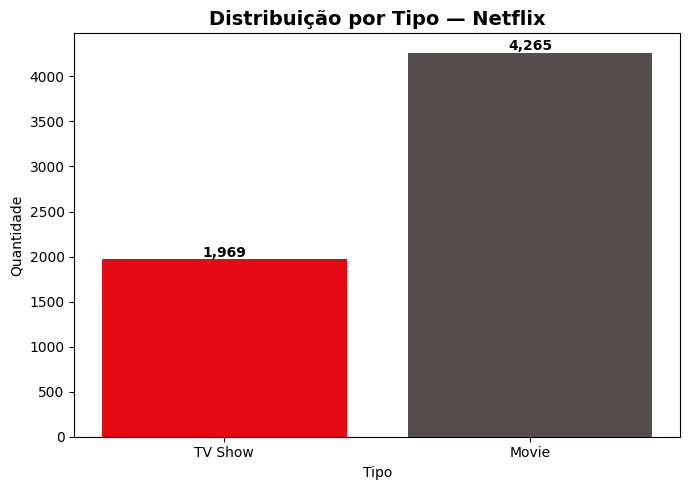

In [ ]:
# ============================================================
# VISUALIZAÇÃO 1 — Distribuição por Tipo
# ============================================================
df_type = df.groupBy("type").count().toPandas()

plt.figure(figsize=(7, 5))
bars = plt.bar(df_type["type"], df_type["count"],
               color=["#E50914", "#564D4D"])
plt.title("Distribuição por Tipo — Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
             f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("grafico_tipo.png", dpi=150)
plt.show()

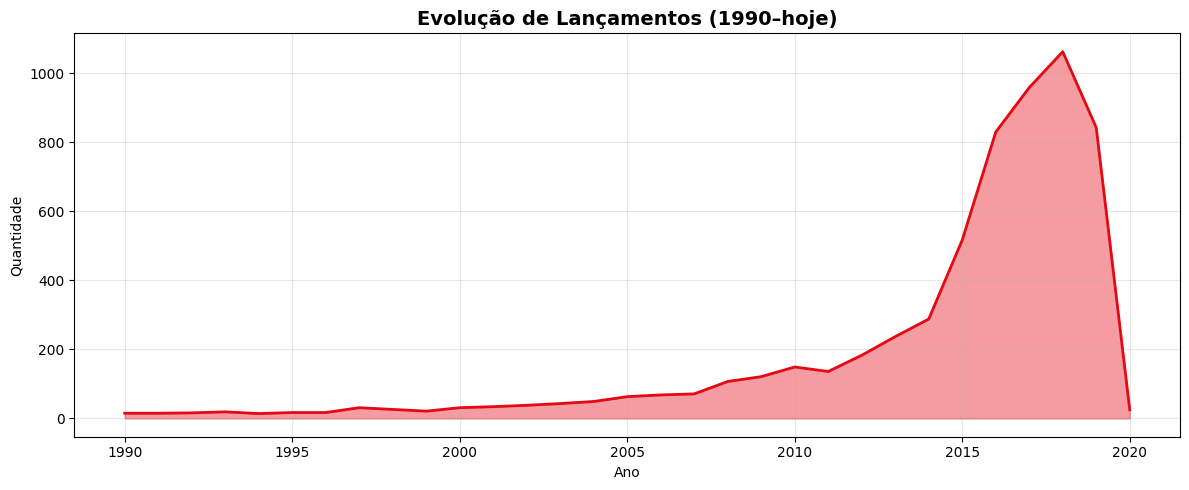

In [ ]:
# ============================================================
# VISUALIZAÇÃO 2 — Evolução de Lançamentos
# ============================================================
df_year = df.groupBy("release_year") \
    .count() \
    .orderBy("release_year") \
    .filter(col("release_year") >= 1990) \
    .toPandas()

plt.figure(figsize=(12, 5))
plt.fill_between(df_year["release_year"], df_year["count"],
                 alpha=0.4, color="#E50914")
plt.plot(df_year["release_year"], df_year["count"],
         color="#E50914", linewidth=2)
plt.title("Evolução de Lançamentos (1990–hoje)", fontsize=14, fontweight="bold")
plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_evolucao.png", dpi=150)
plt.show()

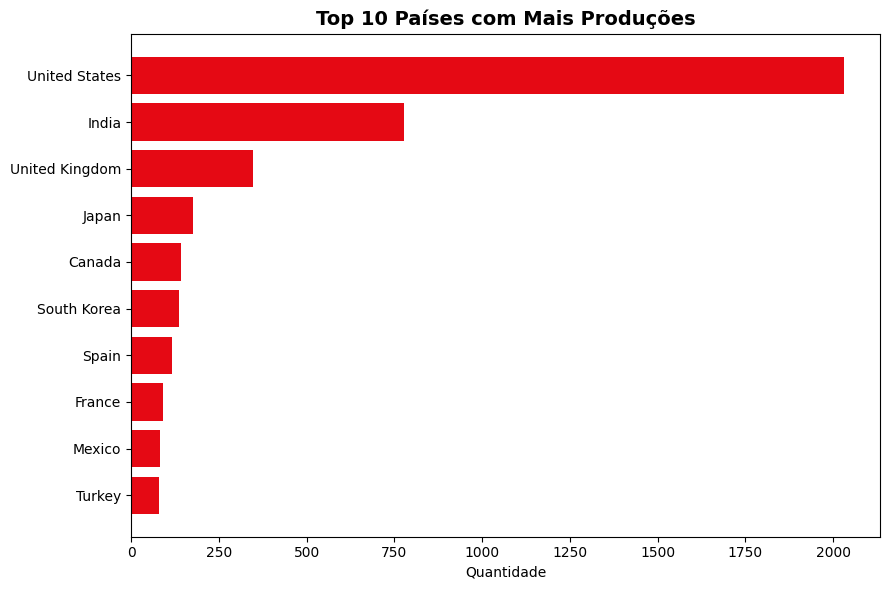

In [ ]:
# ============================================================
# VISUALIZAÇÃO 3 — Top 10 Países
# ============================================================
df_country = df.filter(df.country.isNotNull()) \
    .groupBy("country") \
    .count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(9, 6))
bars = plt.barh(df_country["country"][::-1],
                df_country["count"][::-1],
                color="#E50914")
plt.title("Top 10 Países com Mais Produções", fontsize=14, fontweight="bold")
plt.xlabel("Quantidade")
plt.tight_layout()
plt.savefig("grafico_paises.png", dpi=150)
plt.show()

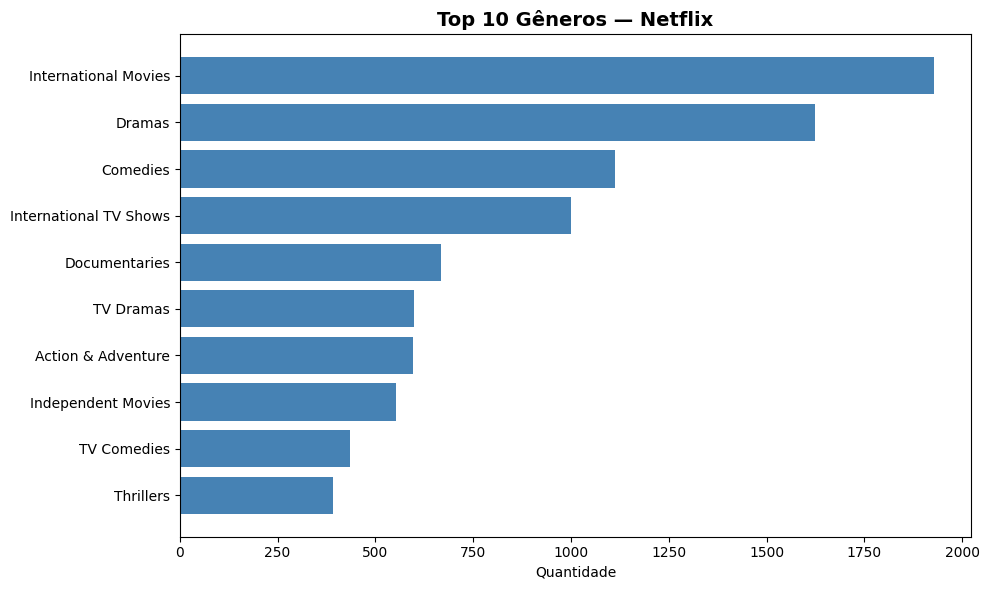

In [ ]:
# ============================================================
# VISUALIZAÇÃO 4 — Top 10 Gêneros (NOVO)
# ============================================================
df_g = df.withColumn("genre", explode(split(col("listed_in"), ", "))) \
         .withColumn("genre", trim(col("genre"))) \
         .groupBy("genre").count() \
         .orderBy(desc("count")) \
         .limit(10) \
         .toPandas()

plt.figure(figsize=(10, 6))
plt.barh(df_g["genre"][::-1], df_g["count"][::-1], color="steelblue")
plt.title("Top 10 Gêneros — Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Quantidade")
plt.tight_layout()
plt.savefig("grafico_generos.png", dpi=150)
plt.show()

## 9. Conclusão e Comparativo Final

In [ ]:
# ============================================================
# COMPARATIVO FINAL — TECNOLOGIAS UTILIZADAS
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║          COMPARATIVO DE TECNOLOGIAS — TEMA 10               ║
╠══════════════════════════════════════════════════════════════╣
║  Tecnologia       │ Uso no Projeto                          ║
╠══════════════════════════════════════════════════════════════╣
║  PySpark          │ Processamento distribuído principal      ║
║  Parquet          │ Armazenamento colunar comprimido         ║
║  Hadoop HDFS      │ Sistema de arquivos distribuído          ║
║  Google BigQuery  │ Data warehouse serverless na nuvem       ║
║  Matplotlib       │ Visualizações dos resultados             ║
╚══════════════════════════════════════════════════════════════╝

✅ CONCEITOS DEMONSTRADOS:
  • Lazy Evaluation: transformações não executam até uma ação
  • Particionamento: divisão dos dados entre workers
  • Predicate Pushdown: Spark lê só partições necessárias
  • Cache: mantém dados em memória para consultas repetidas
  • Integração HDFS: leitura/escrita em sistema distribuído
  • Integração BigQuery: exportação/consulta em data warehouse
""")

In [ ]:
# ============================================================
# ENCERRANDO A SESSÃO SPARK
# Sempre encerre ao final para liberar recursos
# ============================================================
spark.stop()
print("✅ Sessão Spark encerrada.")

✅ Sessão Spark encerrada.
